In [1]:
import torch
import warnings
import random, os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from torch.utils.data import DataLoader, TensorDataset
from matplotlib.colors import LinearSegmentedColormap

import sys
sys.path.append("../..")
from compression.models import Encoder_16, Decoder_16, VAE
from compression.spectral import bandpass, isotropic_spectrum

In [2]:
# cell 1: top of config
MODEL_DIR  = "../../checkpoints/compression"
SAVE_DIR   = "../../results/compression/weighted_spectral"
DATA_PATH  = "../../data/trajectory_real.npy"
os.makedirs(SAVE_DIR, exist_ok=True)
SEED       = 225
K_HF_LO    = 65
k_dealias  = 85
N_SPECTRA  = 400
SPEC_BATCH = 16
eps        = 1e-30

# colormaps 
cmap_full = sns.color_palette("icefire", as_cmap=True)
cmap_hk   = LinearSegmentedColormap.from_list("rbc", [(0,0,1),(1,1,1),(1,0,0)])

# shared dicts
MODEL_LABELS = {
    "A_lat16_mse":      "Model A — MSE",
    "B_lat16_weighted_mse_spec": "Model B — MSE+Spec",
}
STYLES = {
    "A_lat16_mse":      ("#e05c00", "-"),
    "B_lat16_weighted_mse_spec": ("#0077bb", "--"),
}
ZONES = {
    "inertial": dict(k_lo=6,  k_hi=40, label="IR", color="#2ca02c"),
    "mid":      dict(k_lo=40, k_hi=65, label="DO", color="#e67e00"),
    "high_k":   dict(k_lo=65, k_hi=85, label="DD", color="#9b0000"),
}

# data
data      = np.load(DATA_PATH)
train_raw = data[1000:5500]
test_raw  = data[5500:6000]
mu, sigma = train_raw.mean(), train_raw.std()
test_norm = (test_raw - mu) / (sigma + 1e-9)

# Setting up the device:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def add_zones(ax, pad=1.08):
    for z in ZONES.values():
        ax.axvspan(z["k_lo"], z["k_hi"], alpha=0.07, color=z["color"], zorder=0)
        ax.text((z["k_lo"] + z["k_hi"]) / 2, pad, z["label"],
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom",
                fontsize=12, color=z["color"], fontweight="bold")
    ax.axvline(4, color="gray", lw=1.0, ls="--", alpha=0.6)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, which="both", alpha=0.2)

# load models
# helpers
def load_model(name):
    vae = VAE(Encoder_16(1, 8), Decoder_16(8, 1)).to(device)
    ck  = torch.load(f"{MODEL_DIR}/best_{name}.pt", map_location=device)
    vae.load_state_dict(ck["model_state"])
    vae.eval()
    return vae
    
models = {name: load_model(name) for name in MODEL_LABELS}
print("Models loaded.")

Models loaded.


In [4]:
# Helper - torch tensor -> numpy tensor!
def to_np(t):
    return t[:, 0].cpu().numpy() * sigma + mu

def reconstruct(model, x):
    with torch.no_grad():
        mean_z, _ = model.encoder(x)
        return model.decoder(mean_z)

Sample 71  |  p=90%  |  raw support = 10.0% of domain
  IoU — A: 0.138   B: 0.299
  MSE — A: 0.00685   B: 0.007647


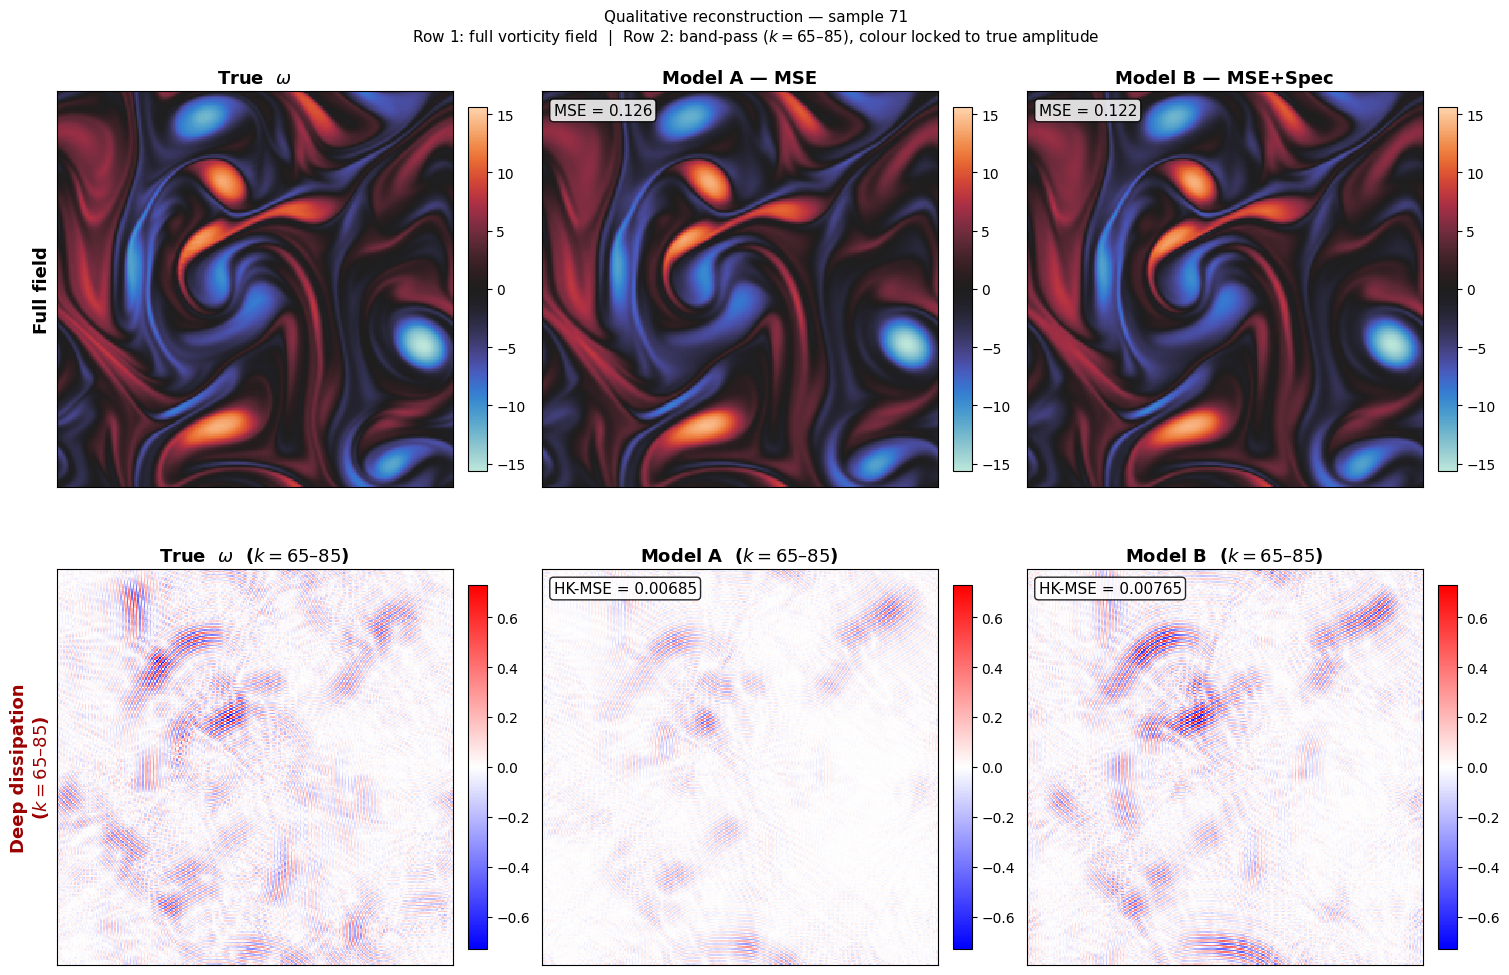

Saved fig5_qualitative.png


In [5]:
# FIGURE A — Rows 1 and 2: full field + DD band-pass
# FIGURE B — Row 3: IoU decomposition (standalone)

import matplotlib.patches as mpatches
from scipy.ndimage import binary_dilation

THRESHOLD_PCT = 90
FS            = 13

# ── Force sample 
idx     = [71]
samples = torch.tensor(test_norm[idx, None],
                       dtype=torch.float32).to(device)

true_np  = to_np(samples)
recon_A  = to_np(reconstruct(models["A_lat16_mse"], samples))
recon_B  = to_np(reconstruct(
    models["B_lat16_weighted_mse_spec"], samples))

mse_A    = ((true_np[0] - recon_A[0])**2).mean()
mse_B    = ((true_np[0] - recon_B[0])**2).mean()

true_hk  = bandpass(true_np[0], K_HF_LO, k_dealias)
recA_hk  = bandpass(recon_A[0], K_HF_LO, k_dealias)
recB_hk  = bandpass(recon_B[0], K_HF_LO, k_dealias)

mse_hk_A = ((true_hk - recA_hk)**2).mean()
mse_hk_B = ((true_hk - recB_hk)**2).mean()

# ── Mask helper
def make_iou_masks(true_dd, model_dd, pct):
    t_mag  = np.abs(true_dd)
    m_mag  = np.abs(model_dd)
    thresh = np.percentile(t_mag, pct)

    t_supp_raw = t_mag > thresh
    m_supp_raw = m_mag > thresh

    inter = np.logical_and(t_supp_raw, m_supp_raw).sum()
    union = np.logical_or( t_supp_raw, m_supp_raw).sum()
    iou   = inter / union if union > 0 else 0.0

    struct     = np.ones((3, 3), dtype=bool)
    t_supp_vis = binary_dilation(t_supp_raw, structure=struct)
    m_supp_vis = binary_dilation(m_supp_raw, structure=struct)

    tp = np.logical_and( t_supp_vis,  m_supp_vis)
    fn = np.logical_and( t_supp_vis, ~m_supp_vis)
    fp = np.logical_and(~t_supp_vis,  m_supp_vis)

    return t_supp_vis, tp, fn, fp, iou, t_supp_raw.mean()


def overlay_iou(ax, tp, fn, fp, title, iou_val):
    H, W  = tp.shape
    rgba  = np.ones((H, W, 4), dtype=float)

    rgba[tp, 0] = 0.0;  rgba[tp, 1] = 0.7;
    rgba[tp, 2] = 0.0;  rgba[tp, 3] = 0.75

    rgba[fn, 0] = 0.85; rgba[fn, 1] = 0.0;
    rgba[fn, 2] = 0.0;  rgba[fn, 3] = 0.75

    rgba[fp, 0] = 1.0;  rgba[fp, 1] = 0.55;
    rgba[fp, 2] = 0.0;  rgba[fp, 3] = 0.60

    no_mask = ~(tp | fn | fp)
    rgba[no_mask, 3] = 0.0

    ax.set_facecolor("white")
    ax.imshow(rgba, origin="lower", interpolation="none")
    ax.set(xticks=[], yticks=[], title=title)
    ax.title.set_fontsize(FS)
    ax.title.set_fontweight("bold")
    ax.text(0.03, 0.97, f"IoU = {iou_val:.3f}",
            transform=ax.transAxes, fontsize=11, va="top",
            bbox=dict(boxstyle="round,pad=0.25",
                      fc="white", alpha=0.92))


# ── Compute masks 
t_supp_ref, _, _, _, _, raw_frac = make_iou_masks(
    true_hk, true_hk, THRESHOLD_PCT)

t_supp_A, tp_A, fn_A, fp_A, iou_A_val, _ = make_iou_masks(
    true_hk, recA_hk, THRESHOLD_PCT)

t_supp_B, tp_B, fn_B, fp_B, iou_B_val, _ = make_iou_masks(
    true_hk, recB_hk, THRESHOLD_PCT)

print(f"Sample {idx[0]}  |  p={THRESHOLD_PCT}%  "
      f"|  raw support = {raw_frac*100:.1f}% of domain")
print(f"  IoU — A: {iou_A_val:.3f}   B: {iou_B_val:.3f}")
print(f"  MSE — A: {mse_hk_A:.4g}   B: {mse_hk_B:.4g}")


# FIGURE A — 2 rows: full field | DD band-pass
fig_a, axes_a = plt.subplots(2, 3, figsize=(15, 10),
                              constrained_layout=True)

# Row 1: Full vorticity
vmax_full = np.abs(true_np[0]).max()
for col, (field, title, annot) in enumerate([
    (true_np[0], r"True  $\omega$",    None),
    (recon_A[0], "Model A — MSE",      f"MSE = {mse_A:.3g}"),
    (recon_B[0], "Model B — MSE+Spec", f"MSE = {mse_B:.3g}"),
]):
    ax = axes_a[0, col]
    im = ax.imshow(field, cmap=cmap_full,
                   vmin=-vmax_full, vmax=vmax_full,
                   origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=[], yticks=[], title=title)
    ax.title.set_fontsize(FS)
    ax.title.set_fontweight("bold")
    if annot:
        ax.text(0.03, 0.97, annot, transform=ax.transAxes,
                fontsize=11, va="top",
                bbox=dict(boxstyle="round,pad=0.25",
                          fc="white", alpha=0.85))

axes_a[0, 0].set_ylabel("Full field", fontsize=FS,
                         fontweight="bold")

# Row 2: DD band-pass
vmax_hk = np.abs(true_hk).max()
for col, (field, title, annot) in enumerate([
    (true_hk,
     f"True  $\\omega$  ($k={K_HF_LO}$–${k_dealias}$)",
     None),
    (recA_hk,
     f"Model A  ($k={K_HF_LO}$–${k_dealias}$)",
     f"HK-MSE = {mse_hk_A:.3g}"),
    (recB_hk,
     f"Model B  ($k={K_HF_LO}$–${k_dealias}$)",
     f"HK-MSE = {mse_hk_B:.3g}"),
]):
    ax = axes_a[1, col]
    im = ax.imshow(field, cmap=cmap_hk,
                   vmin=-vmax_hk, vmax=vmax_hk,
                   origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=[], yticks=[], title=title)
    ax.title.set_fontsize(FS)
    ax.title.set_fontweight("bold")
    if annot:
        ax.text(0.03, 0.97, annot, transform=ax.transAxes,
                fontsize=11, va="top",
                bbox=dict(boxstyle="round,pad=0.25",
                          fc="white", alpha=0.85))

axes_a[1, 0].set_ylabel(
    f"Deep dissipation\n($k={K_HF_LO}$–${k_dealias}$)",
    fontsize=FS, fontweight="bold",
    color=ZONES["high_k"]["color"])

fig_a.suptitle(
    f"Qualitative reconstruction — sample {idx[0]}\n"
    r"Row 1: full vorticity field  $|$  "
    f"Row 2: band-pass ($k={K_HF_LO}$–${k_dealias}$), "
    r"colour locked to true amplitude",
    fontsize=11)

# plt.savefig(f"{SAVE_DIR}/fig5_qualitative.png",
#             dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig5_qualitative.png")

Computing spectra for 400 fields ...
Done.



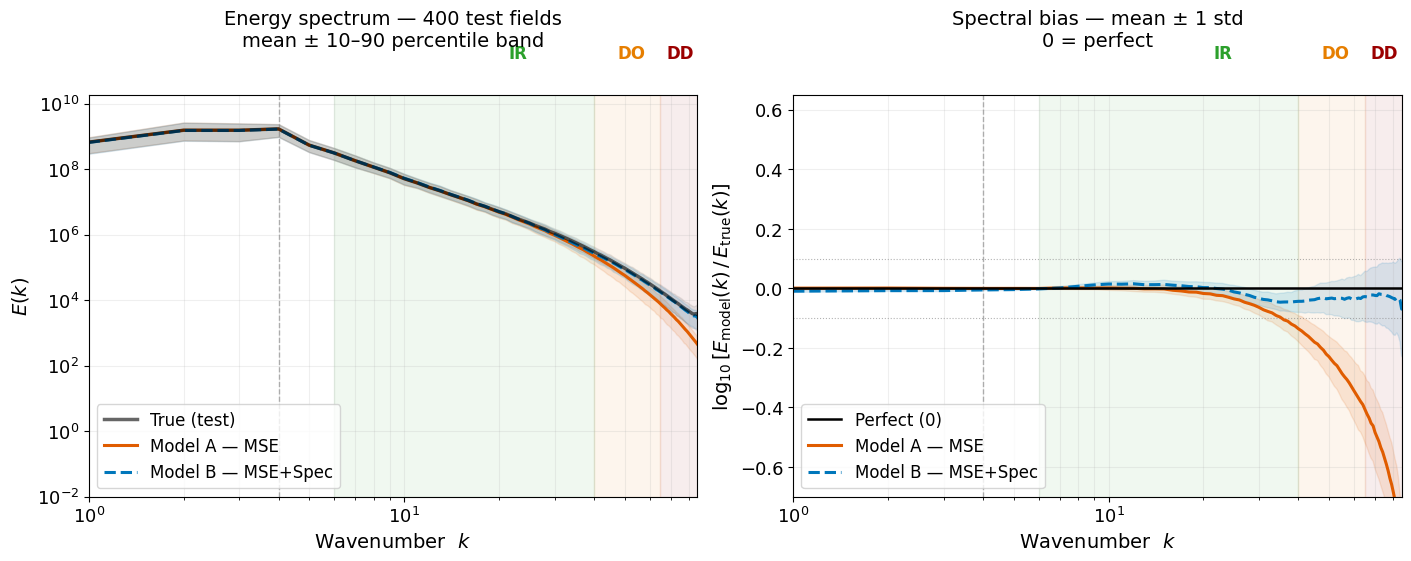

Saved fig5_spectra.png


In [6]:
# FIGURE 5 — ensemble spectra
spec_loader = DataLoader(
    TensorDataset(torch.tensor(test_norm[:N_SPECTRA, None], dtype=torch.float32)),
    batch_size=SPEC_BATCH, shuffle=False)

all_spectra = {"true": [], "A_lat16_mse": [], "B_lat16_weighted_mse_spec": []}
print(f"Computing spectra for {N_SPECTRA} fields ...")

with torch.no_grad():
    for (xb,) in spec_loader:
        xb    = xb.to(device)
        xt_np = xb[:, 0].cpu().numpy() * sigma + mu
        for i in range(xb.size(0)):
            Ei, k_arr = isotropic_spectrum(xt_np[i])
            all_spectra["true"].append(Ei)
        for name in MODEL_LABELS:
            mz, _ = models[name].encoder(xb)
            xhat  = models[name].decoder(mz)
            xh_np = xhat[:, 0].cpu().numpy() * sigma + mu
            for i in range(xb.size(0)):
                E, _ = isotropic_spectrum(xh_np[i])
                all_spectra[name].append(E)

for key in all_spectra:
    all_spectra[key] = np.stack(all_spectra[key])
print("Done.\n")

Et    = all_spectra["true"]
k_ref = 8
E_ref = np.interp(k_ref, k_arr, Et.mean(0))
# k53   = E_ref * (k_arr / k_ref) ** (-5/3)
# k3    = E_ref * (k_arr / k_ref) ** (-3.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
FS = 14

ax1.loglog(k_arr, Et.mean(0), color="black", lw=2.5, label="True (test)", zorder=5, alpha=0.6)
ax1.fill_between(k_arr, np.percentile(Et, 10, axis=0),
                 np.percentile(Et, 90, axis=0), color="black", alpha=0.08)
for name in MODEL_LABELS:
    E = all_spectra[name]; c, ls = STYLES[name]
    ax1.loglog(k_arr, E.mean(0), color=c, lw=2.2, ls=ls, label=MODEL_LABELS[name])
    ax1.fill_between(k_arr, np.percentile(E, 10, axis=0),
                     np.percentile(E, 90, axis=0), color=c, alpha=0.12)
# ax1.loglog(k_arr, k53, color="dimgray", lw=1.1, ls=":",  label=r"$k^{-5/3}$")
# ax1.loglog(k_arr, k3,  color="dimgray", lw=1.1, ls="--", label=r"$k^{-3}$")
add_zones(ax1)
ax1.set_xlim(1, k_dealias); ax1.set_ylim(1e-2, None)
ax1.set_xlabel("Wavenumber  $k$", fontsize=FS)
ax1.set_ylabel("$E(k)$", fontsize=FS)
ax1.set_title(f"Energy spectrum — {N_SPECTRA} test fields\nmean ± 10–90 percentile band",
              fontsize=FS, pad=35)
ax1.legend(fontsize=12, loc="lower left")

ax2.axhline(0,    color="black", lw=1.8, label="Perfect (0)", zorder=5)
ax2.axhline( 0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)
ax2.axhline(-0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)
for name in MODEL_LABELS:
    E = all_spectra[name]; c, ls = STYLES[name]
    lr = np.log10((E + eps) / (Et + eps))
    ax2.semilogx(k_arr, lr.mean(0), color=c, lw=2.2, ls=ls, label=MODEL_LABELS[name])
    ax2.fill_between(k_arr, lr.mean(0) - lr.std(0),
                     lr.mean(0) + lr.std(0), color=c, alpha=0.12)
add_zones(ax2)
ax2.set_xlim(1, k_dealias); ax2.set_ylim(-0.7, 0.65)
ax2.set_xlabel("Wavenumber  $k$", fontsize=FS)
ax2.set_ylabel(r"$\log_{10}[E_\mathrm{model}(k)\,/\,E_\mathrm{true}(k)]$", fontsize=FS)
ax2.set_title("Spectral bias — mean ± 1 std\n0 = perfect", fontsize=FS, pad=35)
ax2.legend(fontsize=12, loc="lower left")

#plt.savefig(f"{SAVE_DIR}/fig5_spectra.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved fig5_spectra.png")

In [7]:
# spectral bias table
ir  = (k_arr >= ZONES["inertial"]["k_lo"]) & (k_arr <= ZONES["inertial"]["k_hi"])
do  = (k_arr >  ZONES["mid"]["k_lo"])      & (k_arr <= ZONES["mid"]["k_hi"])
dd  = (k_arr >  ZONES["high_k"]["k_lo"])   & (k_arr <= ZONES["high_k"]["k_hi"])
ali =  k_arr >  k_dealias

print(f"\n{'Model':<28s}  {'IR bias':>9s}  {'IR sprd':>8s}  "
      f"{'DO bias':>9s}  {'DO sprd':>8s}  "
      f"{'DD bias':>9s}  {'DD sprd':>8s}  {'Alias':>8s}")
print("-" * 105)
for name in MODEL_LABELS:
    lr = np.log10((all_spectra[name] + eps) / (Et + eps))
    print(f"  {MODEL_LABELS[name]:<26s}"
          f"  {lr[:, ir].mean():>+9.4f}  {lr[:, ir].std():>8.4f}"
          f"  {lr[:, do].mean():>+9.4f}  {lr[:, do].std():>8.4f}"
          f"  {lr[:, dd].mean():>+9.4f}  {lr[:, dd].std():>8.4f}"
          f"  {lr[:, ali].mean():>+8.4f}")


Model                           IR bias   IR sprd    DO bias   DO sprd    DD bias   DD sprd     Alias
---------------------------------------------------------------------------------------------------------
  Model A — MSE                 -0.0419    0.0490    -0.2666    0.1138    -0.6057    0.1923   +0.9629
  Model B — MSE+Spec            -0.0127    0.0312    -0.0348    0.0618    -0.0289    0.1120   +1.4686



  Ensemble DD-band MSE  (k = 65–85)   N = 500
  Model A — MSE              mean=0.006199  std=0.002698  median=0.005754  max=0.01603
  Model B — MSE+Spec         mean=0.006696  std=0.002574  median=0.006329  max=0.0156
  Ratio A/B (>1 means B is better): 0.926



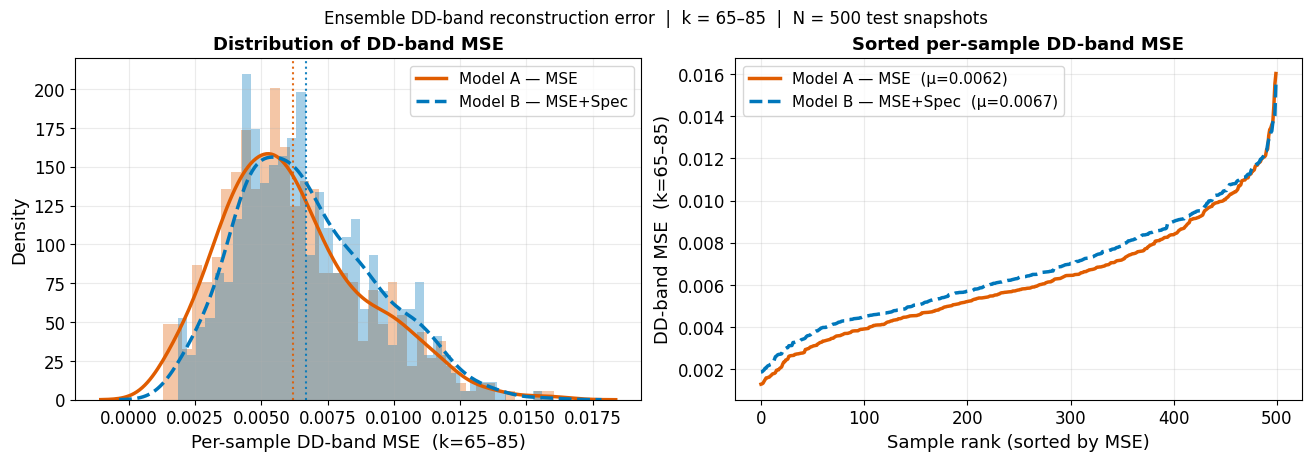

Saved fig_ensemble_dd_mse.png


In [8]:
# ENSEMBLE HIGH-WAVENUMBER (DD) MSE  (k = 65–85)
random.seed(SEED); torch.manual_seed(SEED)

# Build ensemble from the full test set (or a random subset)
N_ENSEMBLE = len(test_norm)          # use all 500 test snapshots; reduce if slow
ens_idx    = list(range(N_ENSEMBLE))

mse_hk_A_list = []
mse_hk_B_list = []

# Process in mini-batches to avoid OOM on GPU
BATCH = 32
for start in range(0, N_ENSEMBLE, BATCH):
    batch_idx  = ens_idx[start : start + BATCH]
    x_batch    = torch.tensor(test_norm[batch_idx, None],
                              dtype=torch.float32).to(device)

    true_batch = to_np(x_batch)                                      # (B, H, W)
    recA_batch = to_np(reconstruct(models["A_lat16_mse"],            x_batch))
    recB_batch = to_np(reconstruct(models["B_lat16_weighted_mse_spec"], x_batch))

    for i in range(len(batch_idx)):
        t_hk = bandpass(true_batch[i], K_HF_LO, k_dealias)          # DD band
        a_hk = bandpass(recA_batch[i], K_HF_LO, k_dealias)
        b_hk = bandpass(recB_batch[i], K_HF_LO, k_dealias)

        mse_hk_A_list.append(((t_hk - a_hk) ** 2).mean())
        mse_hk_B_list.append(((t_hk - b_hk) ** 2).mean())

mse_hk_A_arr = np.array(mse_hk_A_list)
mse_hk_B_arr = np.array(mse_hk_B_list)

# Summary statistics
print(f"\n{'':=<55}")
print(f"  Ensemble DD-band MSE  (k = {K_HF_LO}–{k_dealias})   N = {N_ENSEMBLE}")
print(f"{'':=<55}")
for label, arr in [("Model A — MSE", mse_hk_A_arr),
                   ("Model B — MSE+Spec", mse_hk_B_arr)]:
    print(f"  {label:<25}  mean={arr.mean():.4g}  "
          f"std={arr.std():.4g}  "
          f"median={np.median(arr):.4g}  "
          f"max={arr.max():.4g}")
print(f"{'':=<55}")
ratio = mse_hk_A_arr.mean() / (mse_hk_B_arr.mean() + eps)
print(f"  Ratio A/B (>1 means B is better): {ratio:.3f}\n")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

# Left — histogram / KDE overlay
ax = axes[0]
for label, arr, (color, ls) in [
    ("Model A — MSE",      mse_hk_A_arr, STYLES["A_lat16_mse"]),
    ("Model B — MSE+Spec", mse_hk_B_arr, STYLES["B_lat16_weighted_mse_spec"]),
]:
    ax.hist(arr, bins=40, alpha=0.35, color=color, density=True)
    sns.kdeplot(arr, ax=ax, color=color, lw=2.5, linestyle=ls, label=label)
    ax.axvline(arr.mean(), color=color, lw=1.5, ls=":", alpha=0.9)

ax.set_xlabel(f"Per-sample DD-band MSE  (k={K_HF_LO}–{k_dealias})", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("Distribution of DD-band MSE", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.25)

# Right — sorted error curves (reliability diagram style)
ax = axes[1]
for label, arr, (color, ls) in [
    ("Model A — MSE",      mse_hk_A_arr, STYLES["A_lat16_mse"]),
    ("Model B — MSE+Spec", mse_hk_B_arr, STYLES["B_lat16_weighted_mse_spec"]),
]:
    ax.plot(np.sort(arr), color=color, lw=2.5, linestyle=ls,
            label=f"{label}  (μ={arr.mean():.3g})")

ax.set_xlabel("Sample rank (sorted by MSE)", fontsize=13)
ax.set_ylabel(f"DD-band MSE  (k={K_HF_LO}–{k_dealias})", fontsize=13)
ax.set_title("Sorted per-sample DD-band MSE", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.25)

fig.suptitle(
    f"Ensemble DD-band reconstruction error  |  "
    f"k = {K_HF_LO}–{k_dealias}  |  N = {N_ENSEMBLE} test snapshots",
    fontsize=12)
# plt.savefig(f"{SAVE_DIR}/fig_ensemble_dd_mse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_ensemble_dd_mse.png")

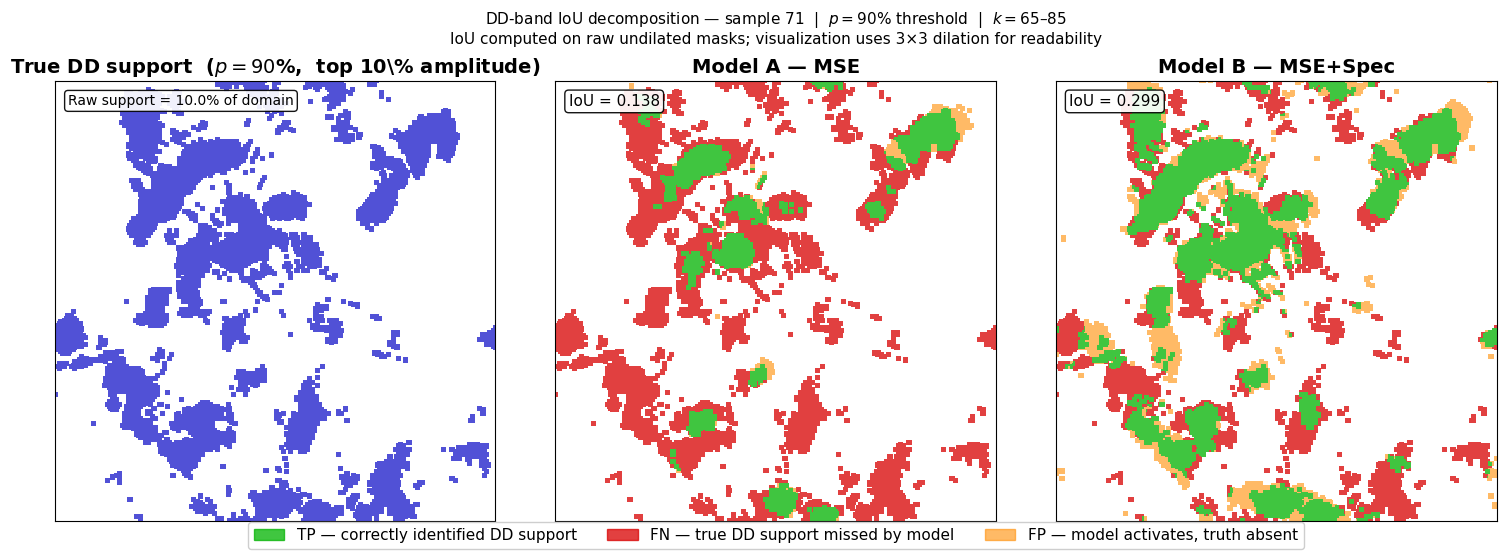

Saved fig5_iou_decomposition.png


In [9]:
# FIGURE B — IoU decomposition (standalone, 1 row × 3 cols)
fig_b, axes_b = plt.subplots(1, 3, figsize=(15, 5.2),
                              constrained_layout=True)

# Panel 0: True DD support reference
ax = axes_b[0]
H, W   = true_hk.shape
rgba_t = np.zeros((H, W, 4), dtype=float)
rgba_t[t_supp_ref, 0] = 0.15
rgba_t[t_supp_ref, 1] = 0.15
rgba_t[t_supp_ref, 2] = 0.80
rgba_t[t_supp_ref, 3] = 0.80
ax.set_facecolor("white")
ax.imshow(rgba_t, origin="lower", interpolation="none")
ax.set(xticks=[], yticks=[],
       title=f"True DD support  ($p={THRESHOLD_PCT}$%,  "
             f"top {100-THRESHOLD_PCT}\\% amplitude)")
ax.title.set_fontsize(FS)
ax.title.set_fontweight("bold")
ax.text(0.03, 0.97,
        f"Raw support = {raw_frac*100:.1f}% of domain",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.25",
                  fc="white", alpha=0.92))

# Panel 1: Model A
overlay_iou(axes_b[1], tp_A, fn_A, fp_A,
            "Model A — MSE", iou_A_val)

# Panel 2: Model B
overlay_iou(axes_b[2], tp_B, fn_B, fp_B,
            "Model B — MSE+Spec", iou_B_val)

# ── Legend as figure-level text below panels
legend_patches = [
    mpatches.Patch(color=(0.0,  0.7,  0.0,  0.75),
                   label="TP — correctly identified DD support"),
    mpatches.Patch(color=(0.85, 0.0,  0.0,  0.75),
                   label="FN — true DD support missed by model"),
    mpatches.Patch(color=(1.0,  0.55, 0.0,  0.60),
                   label="FP — model activates, truth absent"),
]
fig_b.legend(handles=legend_patches,
             fontsize=11,
             loc="lower center",
             ncol=3,
             bbox_to_anchor=(0.5, -0.06),
             framealpha=0.95)

fig_b.suptitle(
    f"DD-band IoU decomposition — sample {idx[0]}  $|$  "
    f"$p={THRESHOLD_PCT}\\%$ threshold  $|$  "
    f"$k={K_HF_LO}$–${k_dealias}$\n"
    "IoU computed on raw undilated masks; "
    "visualization uses 3×3 dilation for readability",
    fontsize=11)

# plt.savefig(f"{SAVE_DIR}/fig5_iou_decomposition.png",
#             dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig5_iou_decomposition.png")

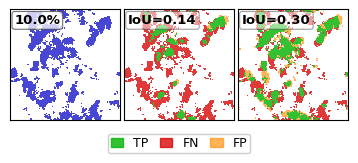

Saved fig5_iou_decomposition_onecol.png


In [10]:
# FIGURE B — IoU decomposition for one-column paper figure
# Target final width: ~3.4 in for a two-column paper single column
fig_b, axes_b = plt.subplots(1, 3,
    figsize=(3.45, 1.55), constrained_layout=False)

# Font sizes tuned for final one-column width
FS_BOX = 9.5
FS_LEG = 9.0
FS_PANEL = 9.0

# Tight spacing between panels
plt.subplots_adjust(left=0.01, right=0.99,
    bottom=0.26, top=0.98, wspace=0.03)

# Panel 0: True DD support
ax = axes_b[0]

H, W = true_hk.shape
rgba_t = np.zeros((H, W, 4), dtype=float)
rgba_t[t_supp_ref, 0] = 0.15
rgba_t[t_supp_ref, 1] = 0.15
rgba_t[t_supp_ref, 2] = 0.80
rgba_t[t_supp_ref, 3] = 0.85

ax.set_facecolor("white")
ax.imshow(rgba_t, origin="lower", interpolation="none")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")   # remove panel heading

ax.text(0.04, 0.96, f"{raw_frac*100:.1f}%", transform=ax.transAxes,
    fontsize=FS_BOX, fontweight="bold", va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.18",
        fc="white", ec="0.25", lw=0.8, alpha=0.75))

# Helper: IoU overlay without titles
def overlay_iou_compact(ax, tp, fn, fp, iou_val):
    H, W = tp.shape
    rgba = np.zeros((H, W, 4), dtype=float)

    # FN: red
    rgba[fn, 0] = 0.85
    rgba[fn, 1] = 0.00
    rgba[fn, 2] = 0.00
    rgba[fn, 3] = 0.78

    # FP: orange
    rgba[fp, 0] = 1.00
    rgba[fp, 1] = 0.55
    rgba[fp, 2] = 0.00
    rgba[fp, 3] = 0.65

    # TP: green, drawn last so overlap is visually clear
    rgba[tp, 0] = 0.00
    rgba[tp, 1] = 0.70
    rgba[tp, 2] = 0.00
    rgba[tp, 3] = 0.80

    ax.set_facecolor("white")
    ax.imshow(rgba, origin="lower", interpolation="none")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("")   # remove panel heading

    ax.text(0.04, 0.96, f"IoU={iou_val:.2f}",
        transform=ax.transAxes, fontsize=FS_BOX, fontweight="bold", va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.25", lw=0.8, alpha=0.50))


# Panel 1: Model A
overlay_iou_compact(axes_b[1], tp_A, fn_A, fp_A, iou_A_val)


# Panel 2: Model B
overlay_iou_compact(axes_b[2], tp_B, fn_B, fp_B, iou_B_val)


# Compact legend
legend_patches = [mpatches.Patch(color=(0.00, 0.70, 0.00, 0.80), label="TP"),
    mpatches.Patch(color=(0.85, 0.00, 0.00, 0.78), label="FN"), mpatches.Patch(color=(1.00, 0.55, 0.00, 0.65), label="FP")]

fig_b.legend(handles=legend_patches, fontsize=FS_LEG, loc="lower center",
    ncol=3, frameon=True, framealpha=0.95, handlelength=1.0, handleheight=0.8, columnspacing=0.9, borderpad=0.25, bbox_to_anchor=(0.5, 0.01))

# Save as vector PDF for the paper, and PNG for quick viewing
plt.savefig(
    f"{SAVE_DIR}/fig5_iou_decomposition_onecol.pdf",
    bbox_inches="tight"
)

plt.show()
print("Saved fig5_iou_decomposition_onecol.png")

Computing swap spectra ...
Done.


Combination                         IR bias   IR sprd    DO bias   DO sprd    DD bias   DD sprd
----------------------------------------------------------------------------------------------------
  $D_A(E_A)$ — baseline             -0.0419    0.0490    -0.2666    0.1138    -0.6057    0.1923
  $D_B(E_B)$ — full Model B         -0.0127    0.0312    -0.0348    0.0618    -0.0289    0.1120
  $D_A(E_B)$ — B enc, A dec         -0.2858    0.1978    -0.7021    0.2032    -0.9613    0.1955
  $D_B(E_A)$ — A enc, B dec         -0.1705    0.2432    -0.3214    0.0982    -0.2277    0.1501


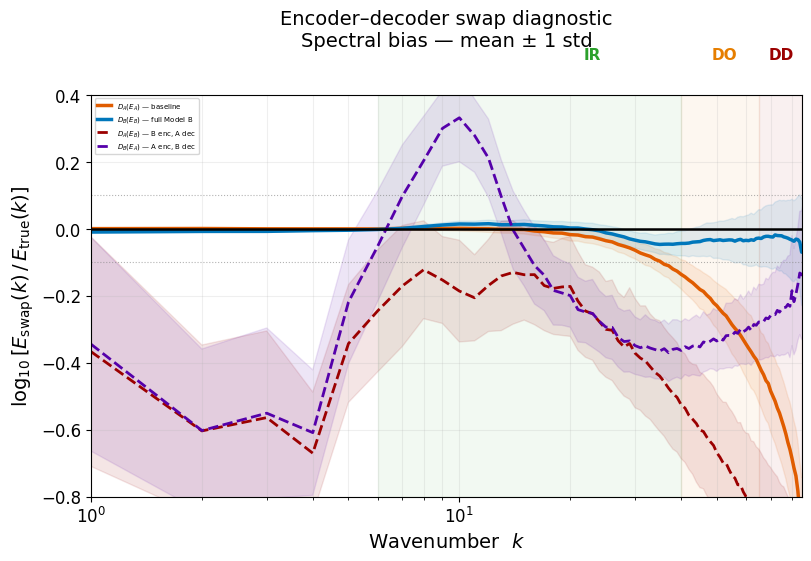

Saved fig_swap_bias.png


In [11]:
# Encoder-Decoder Swap Diagnostic

# load the four components separately
E_A = models["A_lat16_mse"].encoder
D_A = models["A_lat16_mse"].decoder
E_B = models["B_lat16_weighted_mse_spec"].encoder
D_B = models["B_lat16_weighted_mse_spec"].decoder

# set all to eval
for m in [E_A, D_A, E_B, D_B]:
    m.eval()

# cross-swap forward pass
def cross_reconstruct(encoder, decoder, x_gpu):
    with torch.no_grad():
        mean_z, _ = encoder(x_gpu)
        return decoder(mean_z)

# compute spectra for all four combinations
swap_spectra = {
    "DA_EA": [],   # baseline A          — already in all_spectra but recompute for consistency
    "DB_EB": [],   # baseline B          — same
    "DA_EB": [],   # key probe: B enc, A dec
    "DB_EA": [],   # complementary: A enc, B dec
}

swap_configs = {
    "DA_EA": (E_A, D_A),
    "DB_EB": (E_B, D_B),
    "DA_EB": (E_B, D_A),   # note: encoder first, decoder second
    "DB_EA": (E_A, D_B),
}

swap_labels = {
    "DA_EA": r"$D_A(E_A)$ — baseline",
    "DB_EB": r"$D_B(E_B)$ — full Model B",
    "DA_EB": r"$D_A(E_B)$ — B enc, A dec",
    "DB_EA": r"$D_B(E_A)$ — A enc, B dec",
}

print("Computing swap spectra ...")
with torch.no_grad():
    for (xb,) in spec_loader:
        xb    = xb.to(device)
        xt_np = xb[:, 0].cpu().numpy() * sigma + mu

        for key, (enc, dec) in swap_configs.items():
            mean_z, _ = enc(xb)
            xhat      = dec(mean_z)
            xh_np     = xhat[:, 0].cpu().numpy() * sigma + mu
            for i in range(xb.size(0)):
                E, _ = isotropic_spectrum(xh_np[i])
                swap_spectra[key].append(E)

for key in swap_spectra:
    swap_spectra[key] = np.stack(swap_spectra[key])
print("Done.\n")

# spectral bias table
ir = (k_arr >= ZONES["inertial"]["k_lo"]) & (k_arr <= ZONES["inertial"]["k_hi"])
do = (k_arr >  ZONES["mid"]["k_lo"])      & (k_arr <= ZONES["mid"]["k_hi"])
dd = (k_arr >  ZONES["high_k"]["k_lo"])   & (k_arr <= ZONES["high_k"]["k_hi"])

print(f"\n{'Combination':<32s}  {'IR bias':>9s}  {'IR sprd':>8s}  "
      f"{'DO bias':>9s}  {'DO sprd':>8s}  "
      f"{'DD bias':>9s}  {'DD sprd':>8s}")
print("-" * 100)

for key in ["DA_EA", "DB_EB", "DA_EB", "DB_EA"]:
    lr = np.log10((swap_spectra[key] + eps) / (Et + eps))
    print(f"  {swap_labels[key]:<30s}"
          f"  {lr[:, ir].mean():>+9.4f}"
          f"  {lr[:, ir].std():>8.4f}"
          f"  {lr[:, do].mean():>+9.4f}"
          f"  {lr[:, do].std():>8.4f}"
          f"  {lr[:, dd].mean():>+9.4f}"
          f"  {lr[:, dd].std():>8.4f}")

# spectral bias plot — DD zone focus
SWAP_STYLES = {
    "DA_EA": ("#e05c00", "-",  2.5),
    "DB_EB": ("#0077bb", "-",  2.5),
    "DA_EB": ("#9b0000", "--", 2.0),
    "DB_EA": ("#5500aa", "--", 2.0),
}

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

ax.axhline(0,    color="black", lw=1.8, zorder=5)
ax.axhline( 0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)
ax.axhline(-0.1, color="gray",  lw=0.8, ls=":", alpha=0.6)

for key in ["DA_EA", "DB_EB", "DA_EB", "DB_EA"]:
    E  = swap_spectra[key]
    c, ls, lw = SWAP_STYLES[key]
    lr = np.log10((E + eps) / (Et + eps))
    ax.semilogx(k_arr, lr.mean(0), color=c, lw=lw, ls=ls,
                label=swap_labels[key])
    ax.fill_between(k_arr,
                    lr.mean(0) - lr.std(0),
                    lr.mean(0) + lr.std(0),
                    color=c, alpha=0.10)

# zone shading
for z in ZONES.values():
    ax.axvspan(z["k_lo"], z["k_hi"], alpha=0.06, color=z["color"], zorder=0)
    ax.text((z["k_lo"] + z["k_hi"]) / 2, 1.08, z["label"],
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom",
            fontsize=11, color=z["color"], fontweight="bold")

ax.set_xlim(1, k_dealias)
ax.set_ylim(-0.8, 0.40)
ax.set_xlabel("Wavenumber  $k$", fontsize=14)
ax.set_ylabel(r"$\log_{10}[E_\mathrm{swap}(k)\,/\,E_\mathrm{true}(k)]$",
              fontsize=14)
ax.set_title("Encoder–decoder swap diagnostic\nSpectral bias — mean ± 1 std",
             fontsize=14, pad=35)
ax.tick_params(labelsize=12)
ax.grid(True, which="both", alpha=0.2)
ax.legend(fontsize=5, loc="upper left")

# plt.savefig(f"{SAVE_DIR}/fig_swap_bias.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_swap_bias.png")

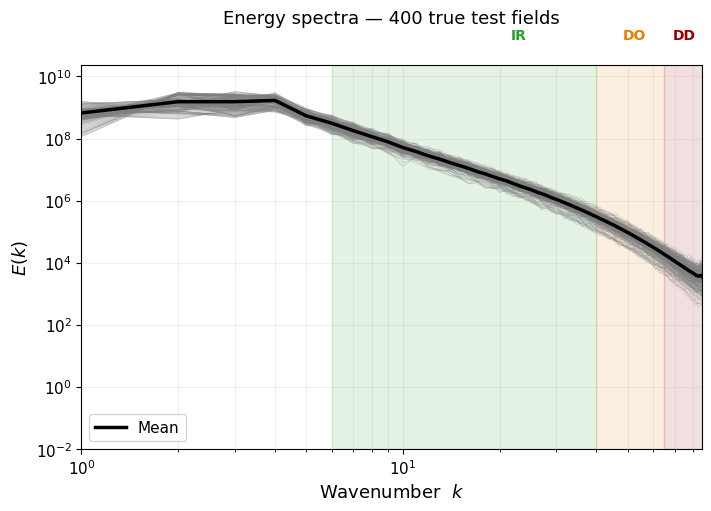

Saved figA_true_spectra.png


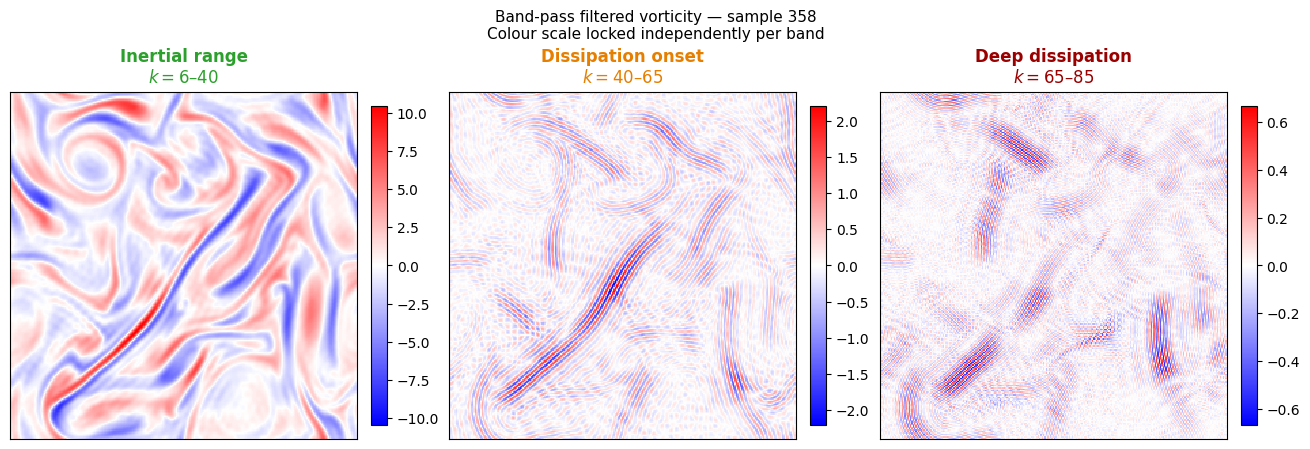

Saved figB_bandpass_zones.png


In [12]:
import random
cmap_hk = LinearSegmentedColormap.from_list("rbc", [(0,0,1),(1,1,1),(1,0,0)])

N_SPEC   = 400

# FIGURE A — spectra of 100 true test fields with zone coloring
spec_loader = DataLoader(
    TensorDataset(torch.tensor(test_norm[:N_SPEC, None], dtype=torch.float32)),
    batch_size=16, shuffle=False)

all_true = []
with torch.no_grad():
    for (xb,) in spec_loader:
        xb    = xb.to(device)
        xt_np = xb[:, 0].cpu().numpy() * sigma + mu
        for i in range(xb.size(0)):
            Ei, k_arr = isotropic_spectrum(xt_np[i])
            all_true.append(Ei)

all_true = np.stack(all_true)   # (100, k_max)
Et_mean  = all_true.mean(0)

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# plot individual spectra in light gray
for i in range(N_SPEC):
    ax.loglog(k_arr, all_true[i], color="gray", lw=0.4, alpha=0.25)

# mean on top
ax.loglog(k_arr, Et_mean, color="black", lw=2.5, label="Mean", zorder=5)

# zone shading + labels
for z in ZONES.values():
    ax.axvspan(z["k_lo"], z["k_hi"], alpha=0.12, color=z["color"], zorder=0)
    ax.text((z["k_lo"] + z["k_hi"]) / 2, 1.06, z["label"],
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom",
            fontsize=10, color=z["color"], fontweight="bold")

ax.set_xlim(1, k_dealias)
ax.set_ylim(1e-2, None)
ax.set_xlabel("Wavenumber  $k$", fontsize=13)
ax.set_ylabel("$E(k)$",          fontsize=13)
ax.set_title(f"Energy spectra — {N_SPEC} true test fields",
             fontsize=13, pad=30)
ax.tick_params(labelsize=11)
ax.grid(True, which="both", alpha=0.2)
ax.legend(fontsize=11)

plt.savefig(f"{SAVE_DIR}/figA_true_spectra.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figA_true_spectra.png")



# FIGURE B — band-pass snapshots: IR | DO | DD for one test field
random.seed(SEED); torch.manual_seed(SEED)
idx    = random.sample(range(len(test_norm)), 1)
field  = test_norm[idx[0]] * sigma + mu   # (H, W) in physical units

bands = {
    "inertial": bandpass(field, ZONES["inertial"]["k_lo"], ZONES["inertial"]["k_hi"]),
    "mid":      bandpass(field, ZONES["mid"]["k_lo"],      ZONES["mid"]["k_hi"]),
    "high_k":   bandpass(field, ZONES["high_k"]["k_lo"],   ZONES["high_k"]["k_hi"]),
}

titles = {
    "inertial": f"Inertial range\n$k = {ZONES['inertial']['k_lo']}$–${ZONES['inertial']['k_hi']}$",
    "mid":      f"Dissipation onset\n$k = {ZONES['mid']['k_lo']}$–${ZONES['mid']['k_hi']}$",
    "high_k":   f"Deep dissipation\n$k = {ZONES['high_k']['k_lo']}$–${ZONES['high_k']['k_hi']}$",
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)

for ax, (key, bfield) in zip(axes, bands.items()):
    vlim = np.abs(bfield).max()
    im   = ax.imshow(bfield, cmap=cmap_hk,
                     vmin=-vlim, vmax=vlim,
                     origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=[], yticks=[])
    ax.set_title(titles[key], fontsize=12, fontweight="bold",
                 color=ZONES[key]["color"], pad=7)

fig.suptitle(f"Band-pass filtered vorticity — sample {idx[0]}\n"
             "Colour scale locked independently per band",
             fontsize=11)

# plt.savefig(f"{SAVE_DIR}/figB_bandpass_zones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figB_bandpass_zones.png")

## Saving the Latents - both mean and latent!:

In [13]:
# # Save train latents for Flow Matching (posterior samples, not means)
# print("Extracting train latents ...")
# train_loader = DataLoader(
#     TensorDataset(torch.tensor(
#         ((data[1000:5500] - mu) / (sigma + 1e-9))[:, None],
#         dtype=torch.float32)),
#     batch_size=SPEC_BATCH, shuffle=False)

# for name, model in models.items():
#     latents_mean   = []
#     latents_sample = []
#     with torch.no_grad():
#         for (xb,) in train_loader:
#             xb             = xb.to(device)
#             mean_z, log_var = model.encoder(xb)
#             z_sample        = model.reparameterize(mean_z, log_var)
#             latents_mean.append(mean_z.cpu().numpy())
#             latents_sample.append(z_sample.cpu().numpy())

#     latents_mean   = np.concatenate(latents_mean,   axis=0)  # (4500, 8, 16, 16)
#     latents_sample = np.concatenate(latents_sample, axis=0)  # (4500, 8, 16, 16)

#     path_mean   = f"{SAVE_DIR}/train_latents_{name}.npy"
#     path_sample = f"{SAVE_DIR}/train_latents_{name}_sample.npy"
#     np.save(path_mean,   latents_mean)
#     np.save(path_sample, latents_sample)

#     print(f"  {name}:")
#     print(f"    means   std={latents_mean.std():.4f}   → {path_mean}")
#     print(f"    samples std={latents_sample.std():.4f}  → {path_sample}")

# print("Done.")

In [14]:
# print(f"Model A IR: {10**(-0.041):.3f} --- Model B IR:{10**(-0.0127):.3f}")
# print(f"Model A DO: {10**(-0.266):.3f} --- Model B DO:{10**(-0.0348):.3f}")
# print(f"Model A DD: {10**(-0.6057):.3f} --- Model B DD:{10**(-0.0289):.3f}")

In [15]:
# DD-BAND SUPPORT vs AMPLITUDE DECOMPOSITION DIAGNOSTIC
# Separates spatial (support overlap) from amplitude effects
# Three thresholds: 25th, 50th, 75th percentile of true DD magnitude

THRESHOLDS_PERCENTILE = [25, 50, 75]
K_DD_LO, K_DD_HI      = 65, 85
N_DIAG                 = len(test_norm)   # all 500 test fields

# Storage: keys = percentile, values = lists over fields
results = {
    p: {
        "iou_A":        [],
        "iou_B":        [],
        "amp_ratio_A":  [],
        "amp_ratio_B":  [],
        "prec_A":       [],
        "prec_B":       [],
        "rec_A":        [],
        "rec_B":        [],
    }
    for p in THRESHOLDS_PERCENTILE
}

print(f"Running DD-band support/amplitude diagnostic on {N_DIAG} fields ...")

BATCH = 32
for start in range(0, N_DIAG, BATCH):
    batch_idx = list(range(start, min(start + BATCH, N_DIAG)))
    xb        = torch.tensor(test_norm[batch_idx, None],
                             dtype=torch.float32).to(device)

    true_batch = to_np(xb)
    recA_batch = to_np(reconstruct(models["A_lat16_mse"],            xb))
    recB_batch = to_np(reconstruct(models["B_lat16_weighted_mse_spec"], xb))

    for i in range(len(batch_idx)):
        # Band-pass to DD zone
        t_dd = bandpass(true_batch[i], K_DD_LO, K_DD_HI)
        a_dd = bandpass(recA_batch[i], K_DD_LO, K_DD_HI)
        b_dd = bandpass(recB_batch[i], K_DD_LO, K_DD_HI)

        # Magnitude fields
        t_mag = np.abs(t_dd)
        a_mag = np.abs(a_dd)
        b_mag = np.abs(b_dd)

        for p in THRESHOLDS_PERCENTILE:
            # Threshold based on percentile of TRUE field magnitude
            thresh = np.percentile(t_mag, p)

            # Binary support masks
            t_supp = t_mag > thresh
            a_supp = a_mag > thresh
            b_supp = b_mag > thresh

            # IoU: intersection / union
            def iou(m1, m2):
                inter = np.logical_and(m1, m2).sum()
                union = np.logical_or(m1, m2).sum()
                return inter / union if union > 0 else 0.0

            # Precision and recall (model support vs true support)
            def prec_rec(pred, true):
                tp   = np.logical_and(pred, true).sum()
                prec = tp / pred.sum()  if pred.sum() > 0 else 0.0
                rec  = tp / true.sum() if true.sum() > 0 else 0.0
                return prec, rec

            iou_a = iou(a_supp, t_supp)
            iou_b = iou(b_supp, t_supp)

            prA, reA = prec_rec(a_supp, t_supp)
            prB, reB = prec_rec(b_supp, t_supp)

            # Amplitude ratio within UNION support
            # ratio > 1 means model OVER-amplifies relative to truth
            union_A = np.logical_or(a_supp, t_supp)
            union_B = np.logical_or(b_supp, t_supp)

            amp_ratio_A = (a_mag[union_A].mean() /
                           t_mag[union_A].mean()) if union_A.sum() > 0 else np.nan
            amp_ratio_B = (b_mag[union_B].mean() /
                           t_mag[union_B].mean()) if union_B.sum() > 0 else np.nan

            results[p]["iou_A"].append(iou_a)
            results[p]["iou_B"].append(iou_b)
            results[p]["amp_ratio_A"].append(amp_ratio_A)
            results[p]["amp_ratio_B"].append(amp_ratio_B)
            results[p]["prec_A"].append(prA)
            results[p]["prec_B"].append(prB)
            results[p]["rec_A"].append(reA)
            results[p]["rec_B"].append(reB)

# Convert to arrays
for p in THRESHOLDS_PERCENTILE:
    for k in results[p]:
        results[p][k] = np.array(results[p][k])

print("Done.\n")

# ── Summary Table
print("=" * 80)
print(f"  DD-BAND SUPPORT vs AMPLITUDE DIAGNOSTIC  "
      f"(k={K_DD_LO}–{K_DD_HI}, N={N_DIAG})")
print("=" * 80)
print(f"\n{'Threshold':>10s}  {'Model':>12s}  "
      f"{'IoU':>8s}  {'Precision':>10s}  {'Recall':>8s}  "
      f"{'Amp Ratio':>10s}")
print("-" * 70)

for p in THRESHOLDS_PERCENTILE:
    r = results[p]
    for model_tag, iou_k, prec_k, rec_k, amp_k in [
        ("Model A",
         "iou_A", "prec_A", "rec_A", "amp_ratio_A"),
        ("Model B",
         "iou_B", "prec_B", "rec_B", "amp_ratio_B"),
    ]:
        iou_m  = r[iou_k].mean();  iou_s  = r[iou_k].std()
        prec_m = r[prec_k].mean(); prec_s = r[prec_k].std()
        rec_m  = r[rec_k].mean();  rec_s  = r[rec_k].std()
        amp_m  = r[amp_k].mean();  amp_s  = r[amp_k].std()
        print(f"  p={p:2d}%  {model_tag:>12s}  "
              f"{iou_m:.3f}±{iou_s:.3f}  "
              f"{prec_m:.3f}±{prec_s:.3f}  "
              f"{rec_m:.3f}±{rec_s:.3f}  "
              f"{amp_m:.3f}±{amp_s:.3f}")
    print()

Running DD-band support/amplitude diagnostic on 500 fields ...
Done.

  DD-BAND SUPPORT vs AMPLITUDE DIAGNOSTIC  (k=65–85, N=500)

 Threshold         Model       IoU   Precision    Recall   Amp Ratio
----------------------------------------------------------------------
  p=25%       Model A  0.507±0.033  0.819±0.009  0.572±0.041  0.501±0.058
  p=25%       Model B  0.621±0.018  0.788±0.007  0.745±0.025  0.916±0.085

  p=50%       Model A  0.314±0.043  0.747±0.025  0.352±0.052  0.471±0.062
  p=50%       Model B  0.439±0.029  0.651±0.022  0.574±0.043  0.911±0.092

  p=75%       Model A  0.216±0.048  0.709±0.048  0.238±0.056  0.439±0.069
  p=75%       Model B  0.341±0.040  0.560±0.039  0.467±0.060  0.912±0.106



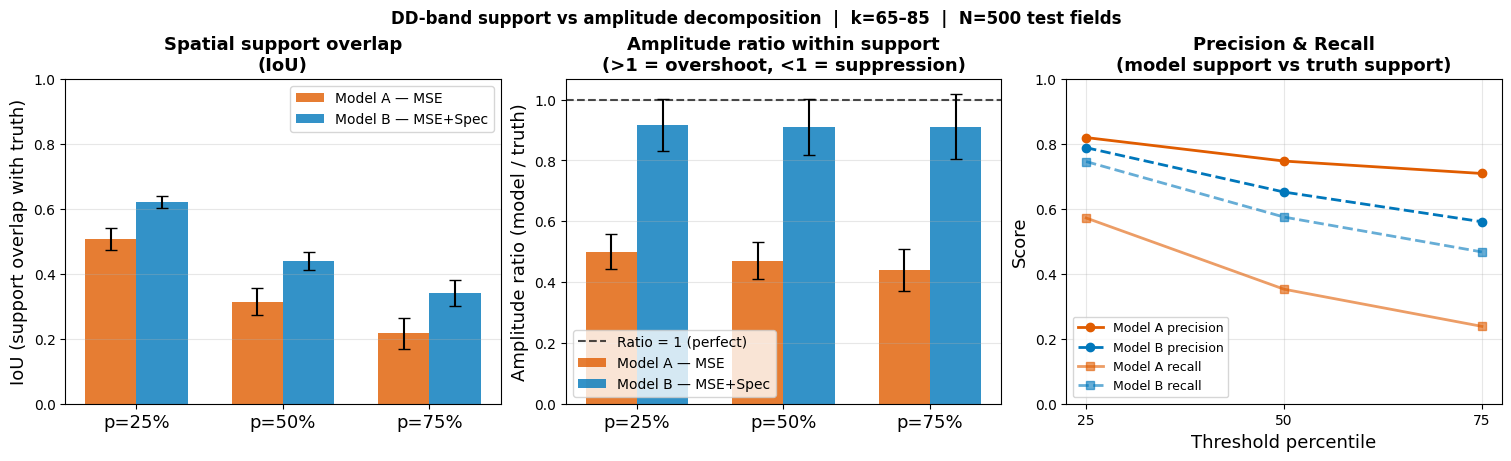

Saved fig_dd_support_amplitude.png


In [16]:
# ── Figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
FS = 13

col_A = STYLES["A_lat16_mse"][0]
col_B = STYLES["B_lat16_weighted_mse_spec"][0]
x     = np.arange(len(THRESHOLDS_PERCENTILE))
w     = 0.35

# Panel 1: IoU
ax = axes[0]
iou_A_means = [results[p]["iou_A"].mean() for p in THRESHOLDS_PERCENTILE]
iou_B_means = [results[p]["iou_B"].mean() for p in THRESHOLDS_PERCENTILE]
iou_A_stds  = [results[p]["iou_A"].std()  for p in THRESHOLDS_PERCENTILE]
iou_B_stds  = [results[p]["iou_B"].std()  for p in THRESHOLDS_PERCENTILE]
ax.bar(x - w/2, iou_A_means, w, yerr=iou_A_stds,
       color=col_A, alpha=0.8, capsize=4, label="Model A — MSE")
ax.bar(x + w/2, iou_B_means, w, yerr=iou_B_stds,
       color=col_B, alpha=0.8, capsize=4, label="Model B — MSE+Spec",
       linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([f"p={p}%" for p in THRESHOLDS_PERCENTILE], fontsize=FS)
ax.set_ylabel("IoU (support overlap with truth)", fontsize=FS)
ax.set_title("Spatial support overlap\n(IoU)", fontsize=FS, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, 1)

# Panel 2: Amplitude ratio
ax = axes[1]
amp_A_means = [results[p]["amp_ratio_A"].mean() for p in THRESHOLDS_PERCENTILE]
amp_B_means = [results[p]["amp_ratio_B"].mean() for p in THRESHOLDS_PERCENTILE]
amp_A_stds  = [results[p]["amp_ratio_A"].std()  for p in THRESHOLDS_PERCENTILE]
amp_B_stds  = [results[p]["amp_ratio_B"].std()  for p in THRESHOLDS_PERCENTILE]
ax.bar(x - w/2, amp_A_means, w, yerr=amp_A_stds,
       color=col_A, alpha=0.8, capsize=4, label="Model A — MSE")
ax.bar(x + w/2, amp_B_means, w, yerr=amp_B_stds,
       color=col_B, alpha=0.8, capsize=4, label="Model B — MSE+Spec")
ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.7, label="Ratio = 1 (perfect)")
ax.set_xticks(x)
ax.set_xticklabels([f"p={p}%" for p in THRESHOLDS_PERCENTILE], fontsize=FS)
ax.set_ylabel("Amplitude ratio (model / truth)", fontsize=FS)
ax.set_title("Amplitude ratio within support\n(>1 = overshoot, <1 = suppression)",
             fontsize=FS, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

# Panel 3: Precision and Recall side by side
ax = axes[2]
prec_A = [results[p]["prec_A"].mean() for p in THRESHOLDS_PERCENTILE]
prec_B = [results[p]["prec_B"].mean() for p in THRESHOLDS_PERCENTILE]
rec_A  = [results[p]["rec_A"].mean()  for p in THRESHOLDS_PERCENTILE]
rec_B  = [results[p]["rec_B"].mean()  for p in THRESHOLDS_PERCENTILE]

ax.plot(THRESHOLDS_PERCENTILE, prec_A, "o-",  color=col_A, lw=2,
        label="Model A precision")
ax.plot(THRESHOLDS_PERCENTILE, prec_B, "o--", color=col_B, lw=2,
        label="Model B precision")
ax.plot(THRESHOLDS_PERCENTILE, rec_A,  "s-",  color=col_A, lw=2,
        alpha=0.6, label="Model A recall")
ax.plot(THRESHOLDS_PERCENTILE, rec_B,  "s--", color=col_B, lw=2,
        alpha=0.6, label="Model B recall")
ax.set_xlabel("Threshold percentile", fontsize=FS)
ax.set_ylabel("Score", fontsize=FS)
ax.set_title("Precision & Recall\n(model support vs truth support)",
             fontsize=FS, fontweight="bold")
ax.set_xticks(THRESHOLDS_PERCENTILE)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"DD-band support vs amplitude decomposition  |  "
    f"k={K_DD_LO}–{K_DD_HI}  |  N={N_DIAG} test fields",
    fontsize=12, fontweight="bold")

# plt.savefig(f"{SAVE_DIR}/fig_dd_support_amplitude.png",
#             dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_dd_support_amplitude.png")

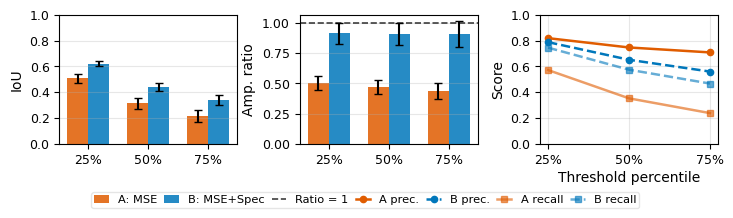

Saved fig_dd_support_amplitude_one_row.png


In [17]:
# Figure: one-row, three-column compact version
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.15), constrained_layout=False)
plt.subplots_adjust(left=0.075, right=0.99, bottom=0.36, top=0.96, wspace=0.35)  # bottom: extra room for xlabel + bottom legend

FS_TICK, FS_LABEL, FS_LEG = 9, 10, 8.2
col_A = STYLES["A_lat16_mse"][0]
col_B = STYLES["B_lat16_weighted_mse_spec"][0]
x = np.arange(len(THRESHOLDS_PERCENTILE))
w = 0.35
xtick_labels = [f"{p}%" for p in THRESHOLDS_PERCENTILE]

# Panel 1: IoU
ax = axes[0]
iou_A_means = [results[p]["iou_A"].mean() for p in THRESHOLDS_PERCENTILE]
iou_B_means = [results[p]["iou_B"].mean() for p in THRESHOLDS_PERCENTILE]
iou_A_stds  = [results[p]["iou_A"].std()  for p in THRESHOLDS_PERCENTILE]
iou_B_stds  = [results[p]["iou_B"].std()  for p in THRESHOLDS_PERCENTILE]
bar_A = ax.bar(x - w/2, iou_A_means, w, yerr=iou_A_stds, color=col_A, alpha=0.85, capsize=3, label="A: MSE")
bar_B = ax.bar(x + w/2, iou_B_means, w, yerr=iou_B_stds, color=col_B, alpha=0.85, capsize=3, label="B: MSE+Spec")
ax.set_xticks(x); ax.set_xticklabels(xtick_labels)
ax.set_ylabel("IoU", fontsize=FS_LABEL)
ax.tick_params(axis="both", labelsize=FS_TICK)
ax.set_ylim(0, 1); ax.grid(True, axis="y", alpha=0.3)

# Panel 2: Amplitude ratio
ax = axes[1]
amp_A_means = [results[p]["amp_ratio_A"].mean() for p in THRESHOLDS_PERCENTILE]
amp_B_means = [results[p]["amp_ratio_B"].mean() for p in THRESHOLDS_PERCENTILE]
amp_A_stds  = [results[p]["amp_ratio_A"].std()  for p in THRESHOLDS_PERCENTILE]
amp_B_stds  = [results[p]["amp_ratio_B"].std()  for p in THRESHOLDS_PERCENTILE]
ax.bar(x - w/2, amp_A_means, w, yerr=amp_A_stds, color=col_A, alpha=0.85, capsize=3)
ax.bar(x + w/2, amp_B_means, w, yerr=amp_B_stds, color=col_B, alpha=0.85, capsize=3)
ratio_line = ax.axhline(1.0, color="black", lw=1.2, ls="--", alpha=0.75, label="Ratio = 1")
ax.set_xticks(x); ax.set_xticklabels(xtick_labels)
ax.set_ylabel("Amp. ratio", fontsize=FS_LABEL)
ax.tick_params(axis="both", labelsize=FS_TICK)
ax.grid(True, axis="y", alpha=0.3)

# Panel 3: Precision and Recall
ax = axes[2]
prec_A = [results[p]["prec_A"].mean() for p in THRESHOLDS_PERCENTILE]
prec_B = [results[p]["prec_B"].mean() for p in THRESHOLDS_PERCENTILE]
rec_A  = [results[p]["rec_A"].mean()  for p in THRESHOLDS_PERCENTILE]
rec_B  = [results[p]["rec_B"].mean()  for p in THRESHOLDS_PERCENTILE]
line_prec_A, = ax.plot(THRESHOLDS_PERCENTILE, prec_A, "o-",  color=col_A, lw=1.8, ms=4.5, label="A prec.")
line_prec_B, = ax.plot(THRESHOLDS_PERCENTILE, prec_B, "o--", color=col_B, lw=1.8, ms=4.5, label="B prec.")
line_rec_A,  = ax.plot(THRESHOLDS_PERCENTILE, rec_A,  "s-",  color=col_A, lw=1.8, ms=4.5, alpha=0.6, label="A recall")
line_rec_B,  = ax.plot(THRESHOLDS_PERCENTILE, rec_B,  "s--", color=col_B, lw=1.8, ms=4.5, alpha=0.6, label="B recall")
ax.set_xlabel("Threshold percentile", fontsize=FS_LABEL, labelpad=3)
ax.set_ylabel("Score", fontsize=FS_LABEL)
ax.set_xticks(THRESHOLDS_PERCENTILE); ax.set_xticklabels(xtick_labels)
ax.set_ylim(0, 1)
ax.tick_params(axis="both", labelsize=FS_TICK)
ax.grid(True, alpha=0.3)

# One compact figure-level legend
handles = [bar_A[0], bar_B[0], ratio_line, line_prec_A, line_prec_B, line_rec_A, line_rec_B]
labels  = ["A: MSE", "B: MSE+Spec", "Ratio = 1", "A prec.", "B prec.", "A recall", "B recall"]
fig.legend(handles, labels, fontsize=FS_LEG, loc="lower center", ncol=7, framealpha=0.5,
           bbox_to_anchor=(0.5, 0.035), handlelength=1.25, columnspacing=0.65, borderpad=0.25, labelspacing=0.25)

# plt.savefig(f"{SAVE_DIR}/fig_dd_support_amplitude_one_row.png", dpi=600, bbox_inches="tight")
plt.show()
print("Saved fig_dd_support_amplitude_one_row.png")

In [18]:
# Ratio A_amp/B_amp: is B consistently above 1 and A below 1?
print("\nAmplitude ratio > 1 means model OVER-amplifies relative to truth.")
print("Expected if story holds: Model A < 1 (suppression), Model B > 1 (overshoot)\n")
for p in THRESHOLDS_PERCENTILE:
    pct_A_above1 = (results[p]["amp_ratio_A"] > 1).mean() * 100
    pct_B_above1 = (results[p]["amp_ratio_B"] > 1).mean() * 100
    print(f"  p={p:2d}%:  "
          f"Model A above 1 in {pct_A_above1:.1f}% of fields  |  "
          f"Model B above 1 in {pct_B_above1:.1f}% of fields")


Amplitude ratio > 1 means model OVER-amplifies relative to truth.
Expected if story holds: Model A < 1 (suppression), Model B > 1 (overshoot)

  p=25%:  Model A above 1 in 0.0% of fields  |  Model B above 1 in 15.4% of fields
  p=50%:  Model A above 1 in 0.0% of fields  |  Model B above 1 in 16.0% of fields
  p=75%:  Model A above 1 in 0.0% of fields  |  Model B above 1 in 21.2% of fields


## GIF for LinkdIN

In [19]:
# LinkedIn GIF: spectral compression preserves fine-scale turbulence
#
# Layout:
#   Top-left      true vorticity field
#   Top-right     instantaneous spectra of truth, MSE, spectral VAE
#   Bottom-left   true DD support
#   Bottom-mid    MSE (Suppression)
#   Bottom-right  MSE + Spectral (Recovery)
#
# Requires in notebook: test_norm, mu, sigma, device, models, bandpass, isotropic_spectrum, SAVE_DIR

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import binary_dilation

# User settings
OUTPUT_GIF = os.path.join(SAVE_DIR, "spectral_compression_dd_support_with_spectrum.gif")

START_INDEX, N_FRAMES, FRAME_STRIDE = 40, 40, 2   # sequential test snapshots
FPS, GIF_DPI = 5, 120

# Solver dt = 5e-4, snapshots stored every 200 steps -> interval 0.1
SNAPSHOT_DT = 0.1
USE_ABSOLUTE_SIMULATION_TIME = False   # False: time relative to test set; True: relative to full dataset
TEST_START_GLOBAL_INDEX = 5500         # test set begins at global snapshot 5500

# Spectral zones
K_FORCE = 4
K_IR_LO, K_IR_HI = 6, 40
K_DO_LO, K_DO_HI = 40, 65
K_DD_LO, K_DD_HI = 65, 85

THRESHOLD_PCT = 90
DILATION_SIZE = 3   # display only; IoU uses undilated masks

MODEL_A_KEY = "A_lat16_mse"
MODEL_B_KEY = "B_lat16_weighted_mse_spec"
SPECTRUM_WIDTH_FACTOR = 0.87   # narrows spectral panel, kept centered

# Frame indices
frame_indices = START_INDEX + FRAME_STRIDE * np.arange(N_FRAMES)
frame_indices = frame_indices[frame_indices < len(test_norm)]
if len(frame_indices) < 2:
    raise ValueError("Not enough test snapshots for the requested animation. "
                     "Reduce START_INDEX, N_FRAMES, or FRAME_STRIDE.")
print(f"Preparing {len(frame_indices)} frames from test indices {frame_indices[0]}–{frame_indices[-1]}")

# Reconstructions
x_all = torch.tensor(test_norm[frame_indices, None], dtype=torch.float32, device=device)
model_A, model_B = models[MODEL_A_KEY], models[MODEL_B_KEY]
model_A.eval(); model_B.eval()
with torch.no_grad():
    mean_A, _ = model_A.encoder(x_all)
    mean_B, _ = model_B.encoder(x_all)
    rec_A_tensor = model_A.decoder(mean_A)
    rec_B_tensor = model_B.decoder(mean_B)

true_fields  = x_all[:, 0].detach().cpu().numpy() * sigma + mu
rec_A_fields = rec_A_tensor[:, 0].detach().cpu().numpy() * sigma + mu
rec_B_fields = rec_B_tensor[:, 0].detach().cpu().numpy() * sigma + mu

# Deep-dissipation band-pass fields
true_dd  = np.stack([bandpass(f, K_DD_LO, K_DD_HI) for f in true_fields])
rec_A_dd = np.stack([bandpass(f, K_DD_LO, K_DD_HI) for f in rec_A_fields])
rec_B_dd = np.stack([bandpass(f, K_DD_LO, K_DD_HI) for f in rec_B_fields])

# Instantaneous spectra
true_spectra, rec_A_spectra, rec_B_spectra = [], [], []
k_arr = None
for i in range(len(frame_indices)):
    spectrum_true, k_this = isotropic_spectrum(true_fields[i])
    spectrum_A, _ = isotropic_spectrum(rec_A_fields[i])
    spectrum_B, _ = isotropic_spectrum(rec_B_fields[i])
    true_spectra.append(spectrum_true); rec_A_spectra.append(spectrum_A); rec_B_spectra.append(spectrum_B)
    if k_arr is None:
        k_arr = np.asarray(k_this)

true_spectra, rec_A_spectra, rec_B_spectra = map(np.stack, (true_spectra, rec_A_spectra, rec_B_spectra))
k_arr = np.asarray(k_arr)

valid_k = np.isfinite(k_arr) & (k_arr > 0) & (k_arr <= K_DD_HI)   # drop k=0 and beyond DD zone
k_plot = k_arr[valid_k]

SPECTRAL_EPS = 1e-30   # protects log plotting from zeros
true_spectra_plot  = np.maximum(true_spectra[:, valid_k],  SPECTRAL_EPS)
rec_A_spectra_plot = np.maximum(rec_A_spectra[:, valid_k], SPECTRAL_EPS)
rec_B_spectra_plot = np.maximum(rec_B_spectra[:, valid_k], SPECTRAL_EPS)

all_spectral_values = np.concatenate([true_spectra_plot.ravel(), rec_A_spectra_plot.ravel(), rec_B_spectra_plot.ravel()])
all_spectral_values = all_spectral_values[np.isfinite(all_spectral_values) & (all_spectral_values > SPECTRAL_EPS)]
spectrum_ymin = 10 ** (np.floor(np.log10(all_spectral_values.min())) - 0.15)
spectrum_ymax = 10 ** (np.ceil(np.log10(all_spectral_values.max())) + 0.05)

# Support and IoU helpers
dilation_structure = np.ones((DILATION_SIZE, DILATION_SIZE), dtype=bool)


def calculate_iou_masks(true_band, model_band, percentile):
    """Threshold from the true DD field, applied to both fields.
    IoU is computed on raw masks; dilation is for visualization only."""
    true_magnitude, model_magnitude = np.abs(true_band), np.abs(model_band)
    threshold = np.percentile(true_magnitude, percentile)
    true_raw, model_raw = true_magnitude > threshold, model_magnitude > threshold

    intersection = np.logical_and(true_raw, model_raw).sum()
    union = np.logical_or(true_raw, model_raw).sum()
    iou = intersection / union if union > 0 else 0.0

    true_visual  = binary_dilation(true_raw,  structure=dilation_structure)
    model_visual = binary_dilation(model_raw, structure=dilation_structure)

    return {
        "true_raw": true_raw, "model_raw": model_raw, "true_visual": true_visual,
        "tp": np.logical_and(true_visual, model_visual),
        "fn": np.logical_and(true_visual, ~model_visual),
        "fp": np.logical_and(~true_visual, model_visual),
        "iou": iou, "threshold": threshold, "support_fraction": true_raw.mean(),
    }


def true_support_rgba(mask):
    """Blue RGBA representation of true DD support."""
    height, width = mask.shape
    rgba = np.ones((height, width, 4), dtype=float)
    rgba[..., 3] = 0.0
    rgba[mask] = [0.10, 0.25, 0.82, 0.92]
    return rgba


def comparison_rgba(tp, fn, fp):
    """Green = true positive, red = false negative, orange = false positive."""
    height, width = tp.shape
    rgba = np.ones((height, width, 4), dtype=float)
    rgba[..., 3] = 0.0
    rgba[fn] = [0.86, 0.05, 0.05, 0.86]
    rgba[fp] = [1.00, 0.53, 0.00, 0.80]
    rgba[tp] = [0.00, 0.63, 0.14, 0.92]
    return rgba


# Precompute support diagnostics
n = len(frame_indices)
diagnostics_A = [calculate_iou_masks(true_dd[i], rec_A_dd[i], THRESHOLD_PCT) for i in range(n)]
diagnostics_B = [calculate_iou_masks(true_dd[i], rec_B_dd[i], THRESHOLD_PCT) for i in range(n)]
true_mask_rgba = [true_support_rgba(diagnostics_A[i]["true_visual"]) for i in range(n)]
model_A_rgba = [comparison_rgba(diagnostics_A[i]["tp"], diagnostics_A[i]["fn"], diagnostics_A[i]["fp"]) for i in range(n)]
model_B_rgba = [comparison_rgba(diagnostics_B[i]["tp"], diagnostics_B[i]["fn"], diagnostics_B[i]["fp"]) for i in range(n)]

# Vorticity color scale
vorticity_limit = np.percentile(np.abs(true_fields), 99.7)
cmap_vorticity = LinearSegmentedColormap.from_list("vorticity_linkedin", [
    (0.00, "#173b8f"), (0.25, "#4388c7"), (0.50, "#f7f7f7"), (0.75, "#dc6a4f"), (1.00, "#8c1426")])

# Figure and grid
plt.close("all")
fig = plt.figure(figsize=(12, 8.4), facecolor="white")
grid = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[1.02, 1.0], left=0.055, right=0.965,
                        bottom=0.125, top=0.865, wspace=0.16, hspace=0.26)

ax_full      = fig.add_subplot(grid[0, 0])
ax_spectrum  = fig.add_subplot(grid[0, 1:3])
ax_true_mask = fig.add_subplot(grid[1, 0])
ax_model_A   = fig.add_subplot(grid[1, 1])
ax_model_B   = fig.add_subplot(grid[1, 2])

# Narrow the spectral axis symmetrically
spectrum_position = ax_spectrum.get_position()
original_center_x = spectrum_position.x0 + spectrum_position.width / 2
new_spectrum_width = spectrum_position.width * SPECTRUM_WIDTH_FACTOR
new_spectrum_x0 = original_center_x - new_spectrum_width / 2
ax_spectrum.set_position([new_spectrum_x0, spectrum_position.y0, new_spectrum_width, spectrum_position.height])

# Title and subtitle
fig.suptitle("Spectral compression preserves fine-scale turbulence", fontsize=18, fontweight="semibold", y=0.965)
fig.text(0.5, 0.918,
         rf"Deep-dissipation support: $k={K_DD_LO}$–${K_DD_HI}$  |  top {100 - THRESHOLD_PCT}% of true DD amplitude",
         ha="center", va="center", fontsize=10.8, color="0.31")

# Image axes
for axis in [ax_full, ax_true_mask, ax_model_A, ax_model_B]:
    axis.set_xticks([]); axis.set_yticks([])
    axis.set_facecolor("white")
    for spine in axis.spines.values():
        spine.set_linewidth(0.8); spine.set_edgecolor("0.72")

full_image = ax_full.imshow(true_fields[0], cmap=cmap_vorticity, vmin=-vorticity_limit, vmax=vorticity_limit,
                            origin="lower", interpolation="none")
true_mask_image = ax_true_mask.imshow(true_mask_rgba[0], origin="lower", interpolation="none")
model_A_image   = ax_model_A.imshow(model_A_rgba[0],   origin="lower", interpolation="none")
model_B_image   = ax_model_B.imshow(model_B_rgba[0],   origin="lower", interpolation="none")

ax_full.text(0.03, 0.97, "True vorticity", transform=ax_full.transAxes, ha="left", va="top", fontsize=11,
             fontweight="semibold", color="0.12",
             bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.68", linewidth=0.7, alpha=0.90))

# Spectral panel: zone shading and labels
ax_spectrum.axvspan(K_IR_LO, K_IR_HI, facecolor="#2ca02c", alpha=0.11, zorder=0)
ax_spectrum.axvspan(K_DO_LO, K_DO_HI, facecolor="#e67e00", alpha=0.11, zorder=0)
ax_spectrum.axvspan(K_DD_LO, K_DD_HI, facecolor="#9b0000", alpha=0.10, zorder=0)

zone_label_y = spectrum_ymax / 2.0
for lo, hi, name, color in [(K_IR_LO, K_IR_HI, "IR", "#168418"), (K_DO_LO, K_DO_HI, "DO", "#d66c00"),
                            (K_DD_LO, K_DD_HI, "DD", "#950000")]:
    ax_spectrum.text(np.sqrt(lo * hi), zone_label_y, name, ha="center", va="top", color=color,
                     fontsize=13, fontweight="semibold")

# Forcing wavenumber
ax_spectrum.axvline(K_FORCE, color="#e67e00", linewidth=1.4, linestyle="--", alpha=0.95)
ax_spectrum.text(K_FORCE * 1.05, spectrum_ymin * 2.0, rf"$k_f={K_FORCE}$", rotation=90, ha="left", va="bottom",
                 fontsize=9.5, color="#d66c00")

# Animated spectral curves
line_true, = ax_spectrum.loglog(k_plot, true_spectra_plot[0], color="black", linewidth=2.4, label="True")
line_A, = ax_spectrum.loglog(k_plot, rec_A_spectra_plot[0], color="#e05c00", linewidth=2.0, linestyle="-", label="MSE")
line_B, = ax_spectrum.loglog(k_plot, rec_B_spectra_plot[0], color="#0077bb", linewidth=2.0, linestyle="--",
                             label="MSE + spectral")

ax_spectrum.set_xlim(max(1, k_plot.min()), K_DD_HI)
ax_spectrum.set_ylim(spectrum_ymin, spectrum_ymax)
ax_spectrum.set_xlabel("Wavenumber  $k$", fontsize=11)
ax_spectrum.set_ylabel("$E(k)$", fontsize=11)
ax_spectrum.set_title("Instantaneous reconstruction spectrum", fontsize=12, fontweight="semibold", pad=8)
ax_spectrum.tick_params(axis="both", labelsize=9)
ax_spectrum.grid(True, which="both", alpha=0.16, linewidth=0.6)
ax_spectrum.legend(loc="lower left", fontsize=9, frameon=True, framealpha=0.90)

# Bottom panel titles
ax_true_mask.set_title("True DD support", fontsize=12, fontweight="semibold", pad=7)
ax_model_A.set_title("MSE (Suppression)", fontsize=12, fontweight="semibold", pad=7)
ax_model_B.set_title("MSE + Spectral (Recovery)", fontsize=12, fontweight="semibold", pad=7)

# Dynamic text boxes
box = dict(boxstyle="round,pad=0.27", facecolor="white", edgecolor="0.68", linewidth=0.7, alpha=0.90)
time_text = ax_full.text(0.03, 0.05, "", transform=ax_full.transAxes, ha="left", va="bottom",
                         fontsize=10.5, color="0.12", bbox=box)
support_text = ax_true_mask.text(0.03, 0.965, "", transform=ax_true_mask.transAxes, ha="left", va="top",
                                 fontsize=10.5, fontweight="semibold", color="0.12", bbox=box)
iou_A_text = ax_model_A.text(0.03, 0.965, "", transform=ax_model_A.transAxes, ha="left", va="top",
                             fontsize=11, fontweight="bold", color="0.12", bbox=box)
iou_B_text = ax_model_B.text(0.03, 0.965, "", transform=ax_model_B.transAxes, ha="left", va="top",
                             fontsize=11, fontweight="bold", color="0.12", bbox=box)

# Figure legend and footnote
legend_handles = [
    mpatches.Patch(facecolor="#1a3fc9", edgecolor="none", label="True support"),
    mpatches.Patch(facecolor="#00a126", edgecolor="none", label="TP — recovered"),
    mpatches.Patch(facecolor="#dc1010", edgecolor="none", label="FN — missed"),
    mpatches.Patch(facecolor="#ff8800", edgecolor="none", label="FP — spurious"),
]
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.040), ncol=4, frameon=False,
           fontsize=10.5, handlelength=1.35, columnspacing=1.6)
fig.text(0.5, 0.014, f"IoU is computed on raw masks; {DILATION_SIZE}×{DILATION_SIZE} dilation is used only for display.",
         ha="center", va="bottom", fontsize=8.5, color="0.43")


# Time and dynamic labels
def physical_time_from_frame(frame_number):
    test_index = frame_indices[frame_number]
    if USE_ABSOLUTE_SIMULATION_TIME:
        return (TEST_START_GLOBAL_INDEX + test_index) * SNAPSHOT_DT
    return test_index * SNAPSHOT_DT


def update_dynamic_text(frame_number):
    physical_time = physical_time_from_frame(frame_number)
    if USE_ABSOLUTE_SIMULATION_TIME:
        time_text.set_text(rf"$t = {physical_time:.1f}$")
    else:
        time_text.set_text(rf"$t_{{\mathrm{{test}}}} = {physical_time:.1f}$")
    support_fraction = 100.0 * diagnostics_A[frame_number]["support_fraction"]
    support_text.set_text(f"Active area = {support_fraction:.1f}%")
    iou_A_text.set_text(f"IoU = {diagnostics_A[frame_number]['iou']:.2f}")
    iou_B_text.set_text(f"IoU = {diagnostics_B[frame_number]['iou']:.2f}")


update_dynamic_text(0)


# Animation
def update(frame_number):
    full_image.set_data(true_fields[frame_number])
    true_mask_image.set_data(true_mask_rgba[frame_number])
    model_A_image.set_data(model_A_rgba[frame_number])
    model_B_image.set_data(model_B_rgba[frame_number])
    line_true.set_ydata(true_spectra_plot[frame_number])
    line_A.set_ydata(rec_A_spectra_plot[frame_number])
    line_B.set_ydata(rec_B_spectra_plot[frame_number])
    update_dynamic_text(frame_number)
    return (full_image, true_mask_image, model_A_image, model_B_image, line_true, line_A, line_B,
            time_text, support_text, iou_A_text, iou_B_text)


animation = FuncAnimation(fig, update, frames=len(frame_indices), interval=1000 / FPS, blit=False, repeat=True)

# Save GIF
output_directory = os.path.dirname(OUTPUT_GIF)
if output_directory:
    os.makedirs(output_directory, exist_ok=True)

writer = PillowWriter(fps=FPS, metadata={"title": "Spectrally regularized latent compression for turbulence",
                                         "artist": "Khalid Rafiq"})
animation.save(OUTPUT_GIF, writer=writer, dpi=GIF_DPI)
plt.close(fig)

# Summary
mean_iou_A = np.mean([d["iou"] for d in diagnostics_A])
mean_iou_B = np.mean([d["iou"] for d in diagnostics_B])
duration_seconds = len(frame_indices) / FPS

print("\nGIF successfully saved:")
print(OUTPUT_GIF)
print(f"\nFrames: {len(frame_indices)}")
print(f"Playback rate: {FPS} fps")
print(f"Loop duration: {duration_seconds:.1f} seconds")
print("\nMean raw-mask IoU across animated frames:")
print(f"  MSE (Suppression):          {mean_iou_A:.3f}")
print(f"  MSE + Spectral (Recovery):  {mean_iou_B:.3f}")

Preparing 40 frames from test indices 40–118

GIF successfully saved:
../../results/compression/weighted_spectral/spectral_compression_dd_support_with_spectrum.gif

Frames: 40
Playback rate: 5 fps
Loop duration: 8.0 seconds

Mean raw-mask IoU across animated frames:
  MSE (Suppression):          0.132
  MSE + Spectral (Recovery):  0.271
